In [58]:
import numpy as np
import matplotlib.pylab as plt
import time
import math

from mgdraw_output_reader_NOVO_v03 import DetectionDataStorage

primaries_per_spawn = 1.5e7
number_of_files = 70
number_of_primaries = primaries_per_spawn * number_of_files

Code for making aaaalll the files (run once)

In [ ]:
beam_current = 2 #nA
core_PATH = r"C:\Users\sathu8821\OneDrive - University of Bergen\NOVO\PTB model\Simulations\2025-12_OncoRay_round2"

run_list = [147, 148, 152, 156, 157, 160, 165,
    179, 180, 182, 197, 198, 199, 205, 207,
    208, 209, 210, 211, 212, 213,
    318,
    "D150", "D200", "D250", "D300", "D350", "D400", "D450", "D500"
    ]
for run in run_list:
    PATH = core_PATH + rf"\NOVO{run}\scintillator_interactions"

    file = DetectionDataStorage(PATH, primaries_per_spawn=primaries_per_spawn, max_files=70)
    file.load_data()
    file.filter_hits(beam_current=beam_current, write_hits_to_file=True)
    file.event_builder(write_ngimager_file=True)


Reading 70 scintillator_interactions.txt-files


Total time used on data collection: 1.25 s

-----------ICODE FILTERING-----------
Raw hit filtering complete. Time used: 0.94 s
Total number of lines: 88375
Number of lines kept: 20896 (23.6%)
Number of lines rejected: 67479 (76.4%)

-----------HIT MERGING-----------
Merging complete. Time used: 0.32 s
Overlaps found: 2796
Total number of hit histories > 10/200 keV: 13043
Number of gamma hit histories > 10 keV: 8088
Number of neutron hit histories > 200 keV: 4943
Number of combo hit histories > 200 keV: 12
C:/Users/sathu8821/OneDrive - University of Bergen/NOVO/PTB model/Simulations/2025-12_OncoRay_round2/NOVO147/gamma_hits.txt successfully created
C:/Users/sathu8821/OneDrive - University of Bergen/NOVO/PTB model/Simulations/2025-12_OncoRay_round2/NOVO147/neutron_hits.txt successfully created
Event summary for gammas:
 1 hit : 7853
 2 hits : 113
 3 hits : 3
Event summary for neutrons:
 1 hit : 4803
 2 hits : 70
C:/Users/sathu8821/OneDrive - University of Bergen/NOVO/PTB model/Simulatio

In [53]:
PATH = r"C:\Users\sathu8821\OneDrive - University of Bergen\NOVO\PTB model\Simulations\2025-12_OncoRay_round2\NOVO51_5e9\scintillator_interactions"
#PATH = r"C:\Users\sathu8821\OneDrive - University of Bergen\NOVO\PTB model\Simulations\2025-12_OncoRay_round2\NOVO139\scintillator_interactions"
file = DetectionDataStorage(PATH, primaries_per_spawn=primaries_per_spawn, max_files=70)
file.load_data()

Reading 349 scintillator_interactions.txt-files

c:\Users\sathu8821\OneDrive - University of Bergen\NOVO\Python-skript\mgdraw_output_reader_NOVO_v03.py:544: SyntaxWarning: invalid escape sequence '\ '
  """


IndexError: list index out of range

In [ ]:
beam_current = 2.0 # nA
file.filter_hits(beam_current=beam_current, write_hits_to_file=False)


-----------ICODE FILTERING-----------
Raw hit filtering complete. Time used: 6.56 s
Total number of lines: 564553
Number of lines kept: 126815 (22.5%)
Number of lines rejected: 437738 (77.5%)

-----------HIT MERGING-----------
Merging complete. Time used: 4.09 s
Overlaps found: 17571
Total number of hit histories > 10/200 keV: 67816
Number of gamma hit histories > 10 keV: 42435
Number of neutron hit histories > 200 keV: 25310
Number of combo hit histories > 200 keV: 71
C:/Users/sathu8821/OneDrive - University of Bergen/NOVO/PTB model/Simulations/2025-12_OncoRay_round2/NOVO139/gamma_hits.txt successfully created
C:/Users/sathu8821/OneDrive - University of Bergen/NOVO/PTB model/Simulations/2025-12_OncoRay_round2/NOVO139/neutron_hits.txt successfully created


In [43]:
sum_gamma_energies = file.gamma_hits[:, 7]

#print()
hydrogen_mask = file.gamma_hits[:, 5] == 1
carbon_mask = file.gamma_hits[:, 5] == 6
oxygen_mask = file.gamma_hits[:, 5] == 8
other_mask = ~np.isin(file.gamma_hits[:, 5], [1, 6, 8])

hydrogen_gamma_energies = sum_gamma_energies[hydrogen_mask]
carbon_gamma_energies = sum_gamma_energies[carbon_mask]
oxygen_gamma_energies = sum_gamma_energies[oxygen_mask]
other_gamma_energies = sum_gamma_energies[other_mask]

other_Zs = file.gamma_hits[:, 5][other_mask]
uniqueZs, Z_counts = np.unique(other_Zs, return_counts=True)
for i in range(len(uniqueZs)):
    print(f"{uniqueZs[i]} : {Z_counts[i]}")

0.0 : 1045
3.0 : 534
4.0 : 978
5.0 : 3444
7.0 : 2050
10.0 : 1
13.0 : 10
14.0 : 1
18.0 : 2


In [54]:
def scatter_photon_energy(incoming_photon_energy, scattering_angle):
    # All energies given in MeV, scattering angles in degrees (conversion below)
    # Electron mass 511 keV
    incoming_photon_energy = incoming_photon_energy * 1e6   # Conversion from MeV to ev
    scattering_angle = scattering_angle * math.pi/180
    return (incoming_photon_energy / (1 + (incoming_photon_energy/511000)*(1- math.cos(scattering_angle))))*1e-6

def compton_electron_energy(incoming_photon_energy, scattering_angle):
    # All energies given in MeV, scattering angles in degrees
    return incoming_photon_energy - scatter_photon_energy(incoming_photon_energy, scattering_angle)


"""
Prompt gamma spectroscopy lines (from Hueso-Gonzalez 2018 and Smeets 2012)

0.718 MeV   :   12C -> 10B
1.022 MeV   :   16O -> 10B

1.63 MeV    :   16O -> 14N

2.00 MeV    :   16O -> 11C  or  12C -> 11C
2.04 MeV    :   16O -> 15O

2.223 MeV   :   1H + n -> 2H + gamma
2.31 MeV    :   16O -> 14N

2.74 MeV    :   16O -> 16O
2.79 MeV    :   16O -> N14
2.80 MeV    :   16O -> 11C  or  12C -> 11C
2.87 MeV    :   16O -> 10B  or  12C -> 10B

4.44 MeV    :   16O -> C12  or  12C -> 12C
4.45 MeV    :   16O -> 11B  or  12C -> 11B

5.18 MeV    :   16O -> 15O
5.24 MeV    :   16O -> 15O
5.27 MeV    :   16O -> 15N
5.30 MeV    :   16O -> 15N

6.13 MeV    :   16O -> 16O
6.18 MeV    :   16O -> 15O
"""

compton_edges = [2.00, 2.223, 3.65, 4.44, 5.30, 6.13]

compton_edges = [compton_electron_energy(i, 180) for i in compton_edges]

print(compton_edges)

[1.7734426956328972, 1.9938386120637481, 3.411214953271028, 4.19840272601427, 5.056250562505625, 5.884723201002271]


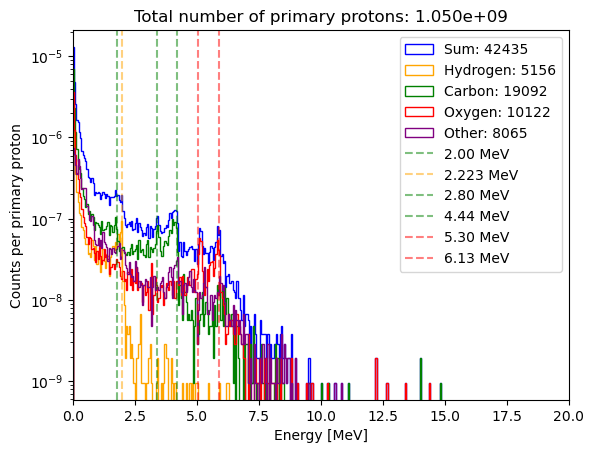

In [45]:
bin_width = 0.05     # MeV
max_energy = 20   # MeV
bins = np.arange(0.0, max_energy + bin_width, bin_width)    # Bins: [0.0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, ..., ]

# Scale frequencies per primary proton
weight_sum = np.ones_like(sum_gamma_energies) / number_of_primaries
weight_hydrogen = np.ones_like(hydrogen_gamma_energies) / number_of_primaries
weight_carbon = np.ones_like(carbon_gamma_energies) / number_of_primaries
weight_oxygen = np.ones_like(oxygen_gamma_energies) / number_of_primaries
weight_other = np.ones_like(other_gamma_energies) / number_of_primaries

plt.hist(sum_gamma_energies, bins, weights=weight_sum, color="blue", label=f"Sum: {len(sum_gamma_energies)}", histtype="step")
plt.hist(hydrogen_gamma_energies, bins, weights=weight_hydrogen, color="orange", label=f"Hydrogen: {len(hydrogen_gamma_energies)}", histtype="step")
plt.hist(carbon_gamma_energies, bins, weights=weight_carbon, color="green", label=f"Carbon: {len(carbon_gamma_energies)}", histtype="step")
plt.hist(oxygen_gamma_energies, bins, weights=weight_oxygen, color="red", label=f"Oxygen: {len(oxygen_gamma_energies)}", histtype="step")
plt.hist(other_gamma_energies, bins, weights=weight_other, color="purple", label=f"Other: {len(other_gamma_energies)}", histtype="step")

compton_lines = True
if compton_lines == True:
    plt.axvline(compton_edges[0], color="green", label="2.00 MeV", ls="--", alpha=0.5)
    plt.axvline(compton_edges[1], color="orange", label="2.223 MeV", ls="--", alpha=0.5)
    plt.axvline(compton_edges[2], color="green", label="2.80 MeV", ls="--", alpha=0.5)
    plt.axvline(compton_edges[3], color="green", label="4.44 MeV", ls="--", alpha=0.5)
    plt.axvline(compton_edges[4], color="red", label="5.30 MeV", ls="--", alpha=0.5)
    plt.axvline(compton_edges[5], color="red", label="6.13 MeV", ls="--", alpha=0.5)

plt.xlim(0, max_energy)
#plt.ylim(1, 50)
#plt.xticks([0.0, 2.5, 5.0, 7.5, 10.0, 12.5, 15.0, 17.5, 20.0])
plt.xticks([2.5 * i for i in range(0, int(max_energy/2.5) + 1)])
plt.yscale("log")
plt.xlabel("Energy [MeV]")
plt.ylabel(f"Counts per primary proton")
plt.title(f"Total number of primary protons: {number_of_primaries:.3e}")
plt.legend()

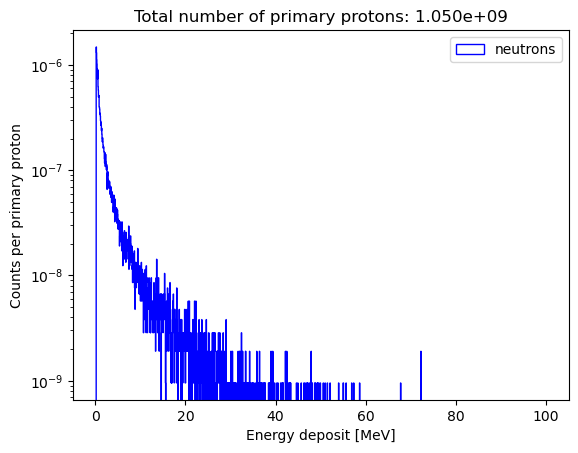

In [46]:
bin_width = 0.05     # MeV
max_energy = 100   # MeV
bins = np.arange(0.0, max_energy + bin_width, bin_width)    # Bins: [0.0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, ..., ]

sum_neutron_energies = file.neutron_hits[:, 7]
weights_neutrons = np.ones_like(sum_neutron_energies) / number_of_primaries

plt.figure()

plt.hist(sum_neutron_energies, bins, weights=weights_neutrons, color="blue", histtype="step", label="neutrons")
plt.xlabel("Energy deposit [MeV]")
plt.ylabel("Counts per primary proton")
plt.yscale("log")
plt.title(f"Total number of primary protons: {number_of_primaries:.3e}")
plt.legend()

In [47]:
icodes = file.all_hits[:, 1]

unc_icd, icd_counts = np.unique(icodes, return_counts=True)
for icd, icd_count in zip(unc_icd, icd_counts):
    print(f"{icd} : {icd_count}")

99.0 : 7
100.0 : 2017
101.0 : 394
106.0 : 823
219.0 : 40403
221.0 : 2032
300.0 : 22069
500.0 : 71


In [48]:
regions = file.all_hits[:, 12]
hit_times = file.all_hits[:, 14]

hit_times_reg = {c: [] for c in range(1, 13)}

for c, t in zip(regions, hit_times):
    hit_times_reg[int(c)].append(t)

hit_times_reg1 = hit_times_reg[1]
hit_times_reg2 = hit_times_reg[2]
hit_times_reg3 = hit_times_reg[3]
hit_times_reg4 = hit_times_reg[4]
hit_times_reg5 = hit_times_reg[5]
hit_times_reg6 = hit_times_reg[6]
hit_times_reg7 = hit_times_reg[7]
hit_times_reg8 = hit_times_reg[8]
hit_times_reg9 = hit_times_reg[9]
hit_times_reg10 = hit_times_reg[10]
hit_times_reg11 = hit_times_reg[11]
hit_times_reg12 = hit_times_reg[12]

(-1000.0, 118003.63027880524)

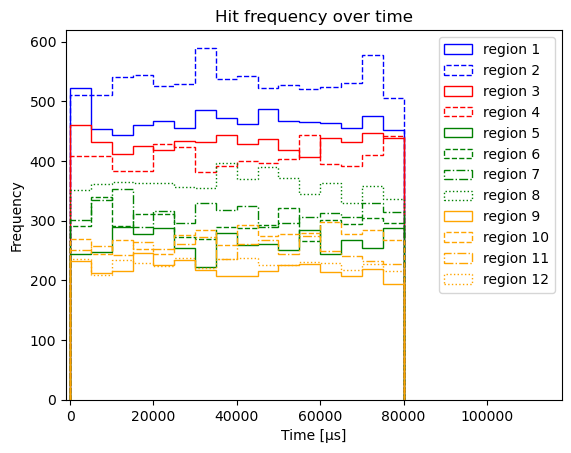

In [49]:
plt.figure()

bin_width = 5000    # µs
max_time = max(hit_times)
bins = np.arange(0.0, max_time, bin_width)

plt.hist(hit_times_reg1, bins, histtype="step", color="blue", label="region 1", ls="-")
plt.hist(hit_times_reg2, bins, histtype="step", color="blue", label="region 2", ls="--")

plt.hist(hit_times_reg3, bins, histtype="step", color="red", label="region 3", ls="-")
plt.hist(hit_times_reg4, bins, histtype="step", color="red", label="region 4", ls="--")

plt.hist(hit_times_reg5, bins, histtype="step", color="green", label="region 5", ls="-")
plt.hist(hit_times_reg6, bins, histtype="step", color="green", label="region 6", ls="--")
plt.hist(hit_times_reg7, bins, histtype="step", color="green", label="region 7", ls="-.")
plt.hist(hit_times_reg8, bins, histtype="step", color="green", label="region 8", ls=":")

plt.hist(hit_times_reg9, bins, histtype="step", color="orange", label="region 9", ls="-")
plt.hist(hit_times_reg10, bins, histtype="step", color="orange", label="region 10", ls="--")
plt.hist(hit_times_reg11, bins, histtype="step", color="orange", label="region 11", ls="-.")
plt.hist(hit_times_reg12, bins, histtype="step", color="orange", label="region 12", ls=":")
plt.xlabel("Time [µs]")
plt.ylabel("Frequency")
plt.legend()
plt.title("Hit frequency over time")
plt.xlim(-1000, max_time*1.4)

In [50]:
# Total counts
for reg in range(1, 13):
    print(f"Region {reg} : {len(hit_times_reg[reg])}")


# Count rate
max_time_in_seconds = max_time/1e6 # From µs to s
for reg in range(1, 13):
    print(f"Region {reg} : {round(len(hit_times_reg[reg])/max_time_in_seconds*0.001, 2)} kcps")

Region 1 : 7841
Region 2 : 8928
Region 3 : 7247
Region 4 : 6804
Region 5 : 4426
Region 6 : 4966
Region 7 : 5252
Region 8 : 6058
Region 9 : 3676
Region 10 : 4584
Region 11 : 4209
Region 12 : 3825
Region 1 : 93.03 kcps
Region 2 : 105.92 kcps
Region 3 : 85.98 kcps
Region 4 : 80.72 kcps
Region 5 : 52.51 kcps
Region 6 : 58.92 kcps
Region 7 : 62.31 kcps
Region 8 : 71.87 kcps
Region 9 : 43.61 kcps
Region 10 : 54.38 kcps
Region 11 : 49.94 kcps
Region 12 : 45.38 kcps


In [51]:
region1_mask = regions==1

region1_times = hit_times[region1_mask]

deadtime_threshold = 0.0
deadtime = 0.4 # µs
clean_hits = 0
overlaps = 0

for hit_time in region1_times:
    if hit_time > deadtime_threshold:
        clean_hits += 1
        deadtime_threshold = hit_time + deadtime
    else:
        overlaps += 1

print(f"Overlaps for region 1 with beam current {beam_current} nA and deadtime {deadtime} µs")
print(f"Isolated hits: {clean_hits} ({round(100 * clean_hits / len(region1_times), 1)}%)")
print(f"Overlaps (or lost hits) {overlaps} ({round(100 * overlaps / len(region1_times), 1)}%)")

Overlaps for region 1 with beam current 2.0 nA and deadtime 0.4 µs
Isolated hits: 3132 (39.9%)
Overlaps (or lost hits) 4709 (60.1%)


In [52]:
file.event_builder(write_ngimager_file=True)

Event summary for gammas:
 1 hit : 41072
 2 hits : 655
 3 hits : 15
 4 hits : 2
Event summary for neutrons:
 1 hit : 24724
 2 hits : 287
 3 hits : 4
C:/Users/sathu8821/OneDrive - University of Bergen/NOVO/PTB model/Simulations/2025-12_OncoRay_round2/NOVO139/FLUKA_NOVO_events.out successfully created
